In [14]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

import aymansigmri as asm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def generate_zte_data_trial(ksp, coord,n_missing,undersampling_factor=1):

    n_spokes, n_points, n_dims = coord.shape
    n_coils = ksp.shape[0]
    half = n_points // 2

    ksp_new = np.zeros((n_coils,n_spokes * 2, half), dtype=ksp.dtype)
    coord_new = np.zeros((n_spokes * 2, half, n_dims), dtype=coord.dtype)
    
    for coil_index in range(n_coils):
        for spoke_index in range(n_spokes):
            spoke_a, spoke_b, coords_a, coords_b = asm.spoke_split(ksp[coil_index,spoke_index], coord[spoke_index])
            
            b_index = asm.get_spoke_b_index(spoke_index, n_spokes)

            ksp_new[coil_index, spoke_index] = spoke_a
            ksp_new[coil_index,b_index] = spoke_b

            coord_new[spoke_index] = coords_a
            coord_new[b_index] = coords_b
    
    coord_full = coord_new.copy()
    ksp_full = ksp_new.copy()
    ksp_groundtruth = ksp_new.copy()
    ksp_full[:, :, :n_missing] = 0


    ksp_new, coord_new = asm.point_remove(kspacedata=ksp_new, coord_data=coord_new, n=n_missing)
    ksp_new, coord_new = asm.spoke_remove(kspacedata=ksp_new, coord_data=coord_new, unsampling=undersampling_factor)

    coord_full = coord_full[::undersampling_factor]
    ksp_full = ksp_full[:, ::undersampling_factor, :]

    n_spokes_full = coord_full.shape[0]
    n_points_full = coord_full.shape[1]
    acquired_mask = np.ones((n_spokes_full, n_points_full), dtype=bool)
    acquired_mask[:, :n_missing] = False

    return ksp_new, coord_new, ksp_full, coord_full, acquired_mask, ksp_groundtruth, n_points_full


In [3]:
zte_radial_kspace, zte_radial_coords, full_zte_radial_kspace, full_zte_radial_coords, zte_mask, groundtruth_radial, n_points_full = generate_zte_data_trial(ksp=ksp, coord=coord, n_missing=1, undersampling_factor=1)

### Trial - One Iter

In [ ]:
def cartesian_data_consistency(kspace_cartsvd, kspace_cartacquired, halfmask_width):
    size = kspace_cartsvd[0,0].shape[0]
    cart_mask = np.ones((size, size),dtype=bool)
    
    cen_x, cen_y = size // 2, size // 2
    cart_mask[cen_x - halfmask_width:cen_x + halfmask_width, cen_y - halfmask_width: cen_y + halfmask_width] = False

    cartesian_kspace_consistent = kspace_cartsvd.copy()

    for coil in range(kspace_cartsvd.shape[0]):
        cartesian_kspace_consistent[coil][cart_mask] = kspace_cartacquired[coil][cart_mask]

    return cartesian_kspace_consistent

#full_zte_radial_coords[:, 0, :] + 128

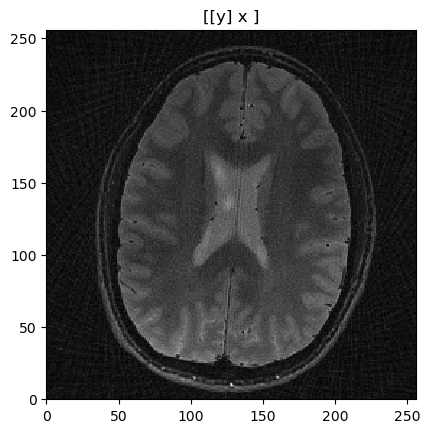

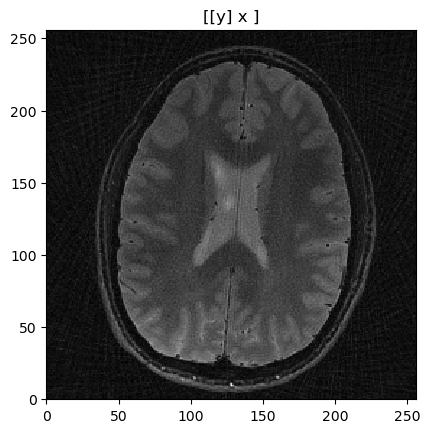

In [8]:
win = 5

kspace_cart_coils = asm.nufft_gridding(kspace=full_zte_radial_kspace, coords=full_zte_radial_coords)
asm.im_recon_cart(kspace=kspace_cart_coils)
hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=kspace_cart_coils, w=win)

U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.2)
data_recon = (U * S_reduced) @ Vh

kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=kspace_cart_coils.shape[0], Nx=kspace_cart_coils.shape[1], Ny=kspace_cart_coils.shape[2], w=win)

kspace_cart_coils_consistent = asm.cartesian_data_consistency(kspace_cartsvd = kspace_cart_coils_recon, kspace_cartacquired=kspace_cart_coils, halfmask_width=1)

asm.im_recon_cart(kspace=kspace_cart_coils_consistent)

In [15]:
kspace_cart_coils_consistent, mask = asm.cartesian_data_consistency(kspace_cartsvd = kspace_cart_coils_recon, kspace_cartacquired=kspace_cart_coils, halfmask_width=1)

In [22]:
filtered = kspace_cart_coils[0][~mask]

In [ ]:

size = kspace_cart_coils[0,0].shape[0]
cart_mask = np.ones((size, size), dtype=bool)

cen_x, cen_y = size // 2, size //2
cart_mask[cen_x - 1:cen_x + 1, cen_y - 1: cen_y + 1] = False

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,

## Try Just in Cartesian Coords

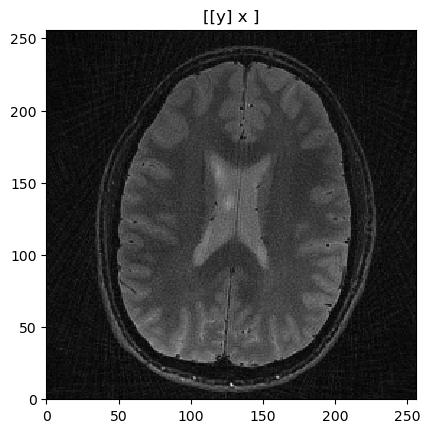

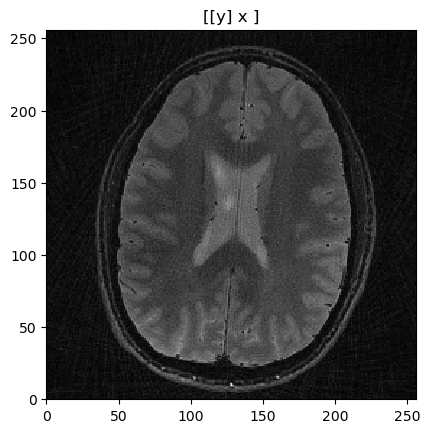

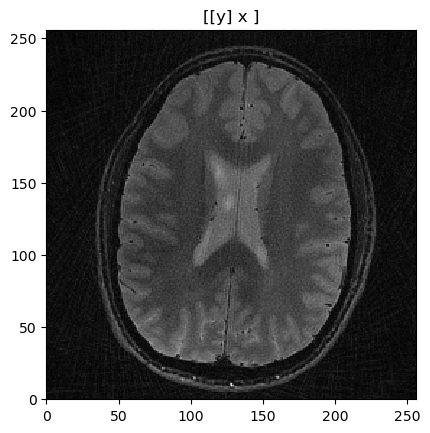

In [10]:
n_iters = 3
kspace_radial = full_zte_radial_kspace.copy()
iter_count = 0

corrected_vals_cart = []
kspace_cart_coils = asm.nufft_gridding(kspace=kspace_radial, coords=full_zte_radial_coords)
kspace_for_recon = kspace_cart_coils



#asm.im_recon_cart(kspace=kspace_cart_coils)
while iter_count < n_iters:
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=kspace_cart_coils, w=5)

    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.4)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H(data_recon, n_coils=kspace_cart_coils.shape[0], Nx=kspace_cart_coils.shape[1], Ny=kspace_cart_coils.shape[2], w=5)

    kspace_cart_coils_consistent = asm.cartesian_data_consistency(kspace_cartsvd = kspace_cart_coils_recon, kspace_cartacquired=kspace_for_recon, halfmask_width=1)


    kspace_cart_coils = kspace_cart_coils_consistent
    
    iter_count += 1
    asm.im_recon_cart(kspace=kspace_cart_coils)
    corrected_vals_cart.append(kspace_radial[0,0,:1])